In [12]:
# Setup
import yaml
import pandas as pd
import numpy as np
from pathlib import Path

from src.analysis.engine import AnalysisEnvironment
from src.analysis.reliability import ReliabilityAnalyzer

from src.prompt_manager import PromptManager

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import scipy.stats as stats

In [13]:
env = AnalysisEnvironment(active_analysis='mcgill_qa_feedback')

# Load everything
final_df, og_df = env.load_data()
pm, prompt_map = env.load_prompts(
    prompt_subfolder='sandbox/MCGILL_QA_FEEDBACK')

Loading files for analysis McGill Feedback Analysis
🐢 Running full processing pipeline...
Results dir: C:\Users\Wouter Barter\Documents\AI_thesis\results\sandbox\MCGILL_QA_FEEDBACK
input_data_path: C:\Users\Wouter Barter\Documents\AI_thesis\data\processed\MCGILL_QA_FEEDBACK_V1.parquet
Loading evaluations...
Filtered to 4 folders based on allowed_models.
📦 Compiling and tokenizing shards for: dataset-mcgill_qa_feedback_model-Qwen-Qwen3.5-4B_prompt-1dfe8cb6857a_prefix-rating
📦 Compiling and tokenizing shards for: dataset-mcgill_qa_feedback_model-Qwen-Qwen3.5-4B_prompt-770268391b2b_prefix-rating
📦 Compiling and tokenizing shards for: dataset-mcgill_qa_feedback_model-Qwen-Qwen3.5-4B_prompt-946e242b933f_prefix-rating
📦 Compiling and tokenizing shards for: dataset-mcgill_qa_feedback_model-Qwen-Qwen3.5-4B_prompt-be0f22b3913e_prefix-rating
📊 Loaded evaluations with top_k values: [500]
Finished loading experiment data
Merging input data and evaluations
Finished merging.
✅ No garbage detected. S

In [14]:
analyzer = ReliabilityAnalyzer(final_df, group_cols=[
                               'model_name', 'prompt_id', 'dimension_name'], llm_rating_col='mean_rating')
analyzer.compute_reliability_gap(metric='spearman')

,model_name,prompt_id,dimension_name,metric_type,spearman_gap,spearman_hh,spearman_llm_avg
1,Qwen/Qwen3.5-4B,1dfe8cb6857a,qa_pair_information_completeness,Spearman,-0.019755,0.560768,0.580524
4,Qwen/Qwen3.5-4B,770268391b2b,qa_pair_overall_answer_quality,Spearman,-0.008632,0.560768,0.569401
5,Qwen/Qwen3.5-4B,946e242b933f,qa_pair_overall_answer_quality,Spearman,-0.006508,0.560768,0.567277
6,Qwen/Qwen3.5-4B,be0f22b3913e,qa_pair_informed_answer_quality,Spearman,-0.004125,0.560768,0.564893
3,Qwen/Qwen3.5-4B,1dfe8cb6857a,qa_pair_topical_relevance,Spearman,0.025867,0.560768,0.534902
0,Qwen/Qwen3.5-4B,1dfe8cb6857a,qa_pair_actionability_and_utility,Spearman,0.072742,0.560768,0.488026
2,Qwen/Qwen3.5-4B,1dfe8cb6857a,qa_pair_structural_clarity,Spearman,0.093928,0.560768,0.466840


In [15]:
analyzer = ReliabilityAnalyzer(
    final_df, group_cols=['model_name', 'prompt_id', 'dimension_name'])
analyzer.analyze_calibration('human_disagreement')

,model_name,prompt_id,dimension_name,calibration_corr
0,Qwen/Qwen3.5-4B,1dfe8cb6857a,qa_pair_actionability_and_utility,0.110627
1,Qwen/Qwen3.5-4B,1dfe8cb6857a,qa_pair_information_completeness,0.192730
2,Qwen/Qwen3.5-4B,1dfe8cb6857a,qa_pair_structural_clarity,0.137977
3,Qwen/Qwen3.5-4B,1dfe8cb6857a,qa_pair_topical_relevance,0.152630
4,Qwen/Qwen3.5-4B,770268391b2b,qa_pair_overall_answer_quality,0.202615
5,Qwen/Qwen3.5-4B,946e242b933f,qa_pair_overall_answer_quality,0.183731
6,Qwen/Qwen3.5-4B,be0f22b3913e,qa_pair_informed_answer_quality,0.150261


# Regressions (predict human rating)

In [16]:
full_model_df = final_df[['input_id', 'prompt_id', 'model_name', 'mean_human_rating',
                          'mode_rating', 'mean_rating', 'dimension_name', 'normalized_entropy']]

In [17]:
pm = PromptManager(folder=Path(
    "../prompts/PromptSuites/sandbox/MCGILL_QA_FEEDBACK"))
pm.load_all()
prompt_hash_map = {key: item.metadata['description']
                   for key, item in pm.suites.items()}

PromptManager initialized with folder: ..\prompts\PromptSuites\sandbox\MCGILL_QA_FEEDBACK
Scanning 6 suites from ..\prompts\PromptSuites\sandbox\MCGILL_QA_FEEDBACK...
Loaded 6 PromptSuites


In [ ]:
def build_formula_from_group(group_df_wide, dimensions, y='mean_human_rating', x_prefix='mean_rating_'):
    # rating_cols = [
    #     f"{x_prefix}{dim}"
    #     for dim in dimensions
    #     if f"{x_prefix}{dim}" in group_df_wide.columns
    # ]
    rating_cols = build_rating_cols(group_df_wide, dimensions, x_prefix)
    return f"{y} ~ " + " + ".join(rating_cols)


def build_rating_cols(group_df_wide, dimensions, prefix):
    rating_cols = [
        f"{prefix}{dim}"
        for dim in dimensions
        if f"{prefix}{dim}" in group_df_wide.columns
    ]
    return rating_cols


def flatten_columns(columns):
    return [
        '_'.join(col).strip('_') if isinstance(col, tuple) else col
        for col in columns
    ]

## Diagnostics

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm

In [ ]:
for (model_name, prompt_id), group_df in full_model_df.groupby(['model_name', 'prompt_id']):
    if prompt_id not in prompt_hash_map:
        print(f"{prompt_id} not in prompts, skipping.")
        continue

    dimensions = sorted(group_df['dimension_name'].dropna().unique())

    if len(dimensions) == 1:
        # print("holistic prompt, sk")
        continue
    else:
        print(f"Model name: {model_name}\nPrompt ID: {prompt_id}")
        group_df_wide = (
            group_df
            .pivot_table(
                index=['input_id', 'mean_human_rating', 'model_name'],
                columns='dimension_name',
                values=['mean_rating', 'normalized_entropy']
            )
            .reset_index()
        )
        group_df_wide.columns = flatten_columns(group_df_wide.columns)
        predictors = build_rating_cols(
            group_df_wide, dimensions, 'mean_rating_')

        X = group_df_wide[predictors].copy()
        X = sm.add_constant(X)

        vif_df = pd.DataFrame({
            'variable': X.columns,
            'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        })
        display(vif_df)
        print(group_df_wide[predictors + ['mean_human_rating']].corr())

Model name: Qwen/Qwen3.5-4B
Prompt ID: 1dfe8cb6857a


,variable,VIF
0,const,39.631286
1,mean_rating_qa_pair_actionability_and_utility,6.064912
2,mean_rating_qa_pair_information_completeness,7.807889
3,mean_rating_qa_pair_structural_clarity,4.046256
4,mean_rating_qa_pair_topical_relevance,4.040304


                                               mean_rating_qa_pair_actionability_and_utility  \
mean_rating_qa_pair_actionability_and_utility                                       1.000000   
mean_rating_qa_pair_information_completeness                                        0.896422   
mean_rating_qa_pair_structural_clarity                                              0.841599   
mean_rating_qa_pair_topical_relevance                                               0.818363   
mean_human_rating                                                                   0.560330   

                                               mean_rating_qa_pair_information_completeness  \
mean_rating_qa_pair_actionability_and_utility                                      0.896422   
mean_rating_qa_pair_information_completeness                                       1.000000   
mean_rating_qa_pair_structural_clarity                                             0.847377   
mean_rating_qa_pair_topical_relevance      

## 'Simple' regression (mean of human evaluations)

In [19]:
models_basic = {}

for group_key, group_df in full_model_df.groupby(['model_name', 'prompt_id']):
    if group_key[1] not in prompt_hash_map.keys():
        print("Key not in prompts, skipping.")
        continue
    if 'quality' in group_df['dimension_name'].unique()[0]:
        formula = 'mean_human_rating ~ mean_rating'
        group_df_wide = group_df
    else:
        group_df_wide = group_df.pivot_table(index=['input_id', 'mean_human_rating', 'model_name'],
                                             columns='dimension_name',
                                             values=['normalized_entropy', 'mean_rating']).reset_index()
        group_df_wide.columns = ['_'.join(col).strip(
            '_') if col[1] else col[0] for col in group_df_wide.columns.values]
        formula = "mean_human_rating ~ mean_rating_qa_pair_actionability_and_utility + mean_rating_qa_pair_information_completeness + mean_rating_qa_pair_structural_clarity + mean_rating_qa_pair_topical_relevance"

    model = smf.ols(formula, data=group_df_wide).fit()

    models_basic[str(
        f"{group_key[0]}_{prompt_hash_map[group_key[1]]}")] = model

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output


def interactive_dataframe_selector(data_dict, description="Select option:"):
    # label -> value pairs; value is the tuple key
    options = [k for k in data_dict.keys()]
    dropdown = widgets.Dropdown(
        options=options,
        description=description,
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    def update_table(change):
        clear_output(wait=True)
        display(dropdown)
        display(data_dict[change.new].summary())

    dropdown.observe(update_table, names='value')
    display(dropdown)
    display(data_dict[dropdown.value].summary())


interactive_dataframe_selector(models_basic)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Qwen/Qwen3.5-4B_Formative Decom…

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      mean_human_rating   R-squared:                       0.437
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     1096.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:45:06   Log-Likelihood:                -6919.7
No. Observations:                5659   AIC:                         1.385e+04
Df Residuals:                    5654   BIC:                         1.388e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=================================================================================================================
                                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                         0.1282      0.069      1.863      0.063      -0.007       0.263
mean_rating_qa_pair_actionability_and_utility    -0.3247      0.051     -6.318      0.000      -0.425      -0.224
mean_rating_qa_pair_information_completeness      1.0857      0.042     25.645      0.000       1.003       1.169
mean_rating_qa_pair_structural_clarity           -0.0526      0.042     -1.262      0.207      -0.134       0.029
mean_rating_qa_pair_topical_relevance             0.1891      0.032      5.838      0.000       0.126       0.253
==============================================================================
Omnibus:                       75.149   Durbin-Watson:                   1.992
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               71.870
Skew:                          -0.244   Prob(JB):                     2.48e-16
Kurtosis:                       2.742   Cond. No.                         41.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Vector regression

In [21]:
import pandas as pd
import statsmodels.formula.api as smf

models_mean = {}

full_model_df = final_df.copy()
llm_prediction_col = 'mean_rating'

for group_key, group_df in full_model_df.groupby(['model_name', 'prompt_id']):
    if group_key[1] not in prompt_hash_map.keys():
        print(f"Key {group_key[1]} not in prompts, skipping.")
        continue

    # 1. Identify if prompt is holistic or formative
    unique_dims = group_df['dimension_name'].unique()
    is_holistic = any('quality' in dim for dim in unique_dims)

    if is_holistic:
        group_df_wide = group_df.copy()
        iv_cols = [llm_prediction_col]
    else:
        # Note: Add 'score_1' and 'score_2' to the index so they survive the pivot
        group_df_wide = group_df.pivot_table(
            index=['input_id', 'score_1', 'score_2', 'model_name'],
            columns='dimension_name',
            values=['normalized_entropy', llm_prediction_col]
        ).reset_index()

        # Flatten the MultiIndex columns created by the pivot
        group_df_wide.columns = [
            f"{col[0]}_{col[1]}".strip('_') if col[1] else col[0]
            for col in group_df_wide.columns.values
        ]

        # Dynamically fetch all dimension columns for the independent variables
        iv_cols = [
            col for col in group_df_wide.columns if col.startswith(llm_prediction_col)]

    # --- DISAGGREGATION & CLUSTERING FIX ---

    # 2. Melt the dataframe to long format (two rows per input_id)
    id_variables = ['input_id', 'model_name'] + iv_cols
    group_df_long = pd.melt(
        group_df_wide,
        id_vars=id_variables,
        value_vars=['score_1', 'score_2'],
        var_name='rater_id',
        value_name='raw_human_rating'
    ).dropna(subset=['raw_human_rating'])  # Drop NAs if some Q&A pairs only had 1 rater

    # 3. Dynamically build the formula targeting the raw human rating
    iv_string = ' + '.join(iv_cols)
    formula = f"raw_human_rating ~ {iv_string}"

    # 4. Fit the OLS model with Standard Errors clustered at the QA-pair level
    model = smf.ols(formula, data=group_df_long).fit(
        cov_type='cluster',
        cov_kwds={'groups': group_df_long['input_id']}
    )

    models_mean[f"{group_key[0]}_{prompt_hash_map[group_key[1]]}"] = model

In [ ]:
interactive_dataframe_selector(models_mean)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Qwen/Qwen3.5-4B_Formative Decom…

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       raw_human_rating   R-squared:                       0.340
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     1735.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:45:31   Log-Likelihood:                -16143.
No. Observations:               11318   AIC:                         3.230e+04
Df Residuals:                   11313   BIC:                         3.233e+04
Df Model:                           4                                         
Covariance Type:              cluster                                         
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                         0.1282      0.057      2.256      0.024       0.017       0.239
mean_rating_qa_pair_actionability_and_utility    -0.3247      0.053     -6.142      0.000      -0.428      -0.221
mean_rating_qa_pair_information_completeness      1.0857      0.042     25.561      0.000       1.002       1.169
mean_rating_qa_pair_structural_clarity           -0.0526      0.042     -1.249      0.212      -0.135       0.030
mean_rating_qa_pair_topical_relevance             0.1891      0.035      5.387      0.000       0.120       0.258
==============================================================================
Omnibus:                      319.629   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              218.256
Skew:                          -0.227   Prob(JB):                     4.04e-48
Kurtosis:                       2.493   Cond. No.                         41.4
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [24]:
# import pandas as pd
# import statsmodels.formula.api as smf

# models = {}

# # full_model_df = final_df[['input_id', 'prompt_id', 'model_name', 'mean_human_rating',
# #                           'mode_rating', 'mean_rating', 'dimension_name', 'normalized_entropy']]

# full_model_df = final_df.copy()

# for group_key, group_df in full_model_df.groupby(['model_name', 'prompt_id']):
#     if group_key[1] not in prompt_hash_map.keys():
#         print(f"Key {group_key[1]} not in prompts, skipping.")
#         continue

#     # 1. Identify if prompt is holistic or formative
#     unique_dims = group_df['dimension_name'].unique()
#     is_holistic = any('quality' in dim for dim in unique_dims)

#     if is_holistic:
#         group_df_wide = group_df.copy()
#         iv_cols = ['mean_rating']
#     else:
#         # Note: Add 'score_1' and 'score_2' to the index so they survive the pivot
#         group_df_wide = group_df.pivot_table(
#             index=['input_id', 'score_1', 'score_2', 'model_name'],
#             columns='dimension_name',
#             values=['normalized_entropy', 'mean_rating']
#         ).reset_index()

#         # Flatten the MultiIndex columns created by the pivot
#         group_df_wide.columns = [
#             f"{col[0]}_{col[1]}".strip('_') if col[1] else col[0]
#             for col in group_df_wide.columns.values
#         ]

#         # Dynamically fetch all dimension columns for the independent variables
#         iv_cols = [
#             col for col in group_df_wide.columns if col.startswith('mean_rating_')]

#     # --- DISAGGREGATION & CLUSTERING FIX ---

#     # 2. Melt the dataframe to long format (two rows per input_id)
#     id_variables = ['input_id', 'model_name'] + iv_cols
#     group_df_long = pd.melt(
#         group_df_wide,
#         id_vars=id_variables,
#         value_vars=['score_1', 'score_2'],
#         var_name='rater_id',
#         value_name='raw_human_rating'
#     ).dropna(subset=['raw_human_rating'])  # Drop NAs if some Q&A pairs only had 1 rater

#     # 3. Dynamically build the formula targeting the raw human rating
#     iv_string = ' + '.join(iv_cols)
#     formula = f"raw_human_rating ~ {iv_string}"

#     # 4. Fit the OLS model with Standard Errors clustered at the QA-pair level
#     model = smf.ols(formula, data=group_df_long).fit(
#         cov_type='cluster',
#         cov_kwds={'groups': group_df_long['input_id']}
#     )

#     models[f"{group_key[0]}_{prompt_hash_map[group_key[1]]}"] = model

In [25]:
import pandas as pd
import statsmodels.formula.api as smf

models_mode = {}

full_model_df = final_df.copy()
llm_prediction_col = 'mode_rating'

for group_key, group_df in full_model_df.groupby(['model_name', 'prompt_id']):
    if group_key[1] not in prompt_hash_map.keys():
        print(f"Key {group_key[1]} not in prompts, skipping.")
        continue

    # 1. Identify if prompt is holistic or formative
    unique_dims = group_df['dimension_name'].unique()
    is_holistic = any('quality' in dim for dim in unique_dims)

    if is_holistic:
        group_df_wide = group_df.copy()
        iv_cols = [llm_prediction_col]
    else:
        # Note: Add 'score_1' and 'score_2' to the index so they survive the pivot
        group_df_wide = group_df.pivot_table(
            index=['input_id', 'score_1', 'score_2', 'model_name'],
            columns='dimension_name',
            values=['normalized_entropy', llm_prediction_col]
        ).reset_index()

        # Flatten the MultiIndex columns created by the pivot
        group_df_wide.columns = [
            f"{col[0]}_{col[1]}".strip('_') if col[1] else col[0]
            for col in group_df_wide.columns.values
        ]

        # Dynamically fetch all dimension columns for the independent variables
        iv_cols = [
            col for col in group_df_wide.columns if col.startswith(llm_prediction_col)]

    # --- DISAGGREGATION & CLUSTERING FIX ---

    # 2. Melt the dataframe to long format (two rows per input_id)
    id_variables = ['input_id', 'model_name'] + iv_cols
    group_df_long = pd.melt(
        group_df_wide,
        id_vars=id_variables,
        value_vars=['score_1', 'score_2'],
        var_name='rater_id',
        value_name='raw_human_rating'
    ).dropna(subset=['raw_human_rating'])  # Drop NAs if some Q&A pairs only had 1 rater

    # 3. Dynamically build the formula targeting the raw human rating
    iv_string = ' + '.join(iv_cols)
    formula = f"raw_human_rating ~ {iv_string}"

    # 4. Fit the OLS model with Standard Errors clustered at the QA-pair level
    model = smf.ols(formula, data=group_df_long).fit(
        cov_type='cluster',
        cov_kwds={'groups': group_df_long['input_id']}
    )

    models_mode[f"{group_key[0]}_{prompt_hash_map[group_key[1]]}"] = model

In [26]:
interactive_dataframe_selector(models_mode)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Qwen/Qwen3.5-4B_Formative Decom…

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       raw_human_rating   R-squared:                       0.310
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     1440.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:45:51   Log-Likelihood:                -16397.
No. Observations:               11318   AIC:                         3.280e+04
Df Residuals:                   11313   BIC:                         3.284e+04
Df Model:                           4                                         
Covariance Type:              cluster                                         
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                         0.3888      0.038     10.115      0.000       0.313       0.464
mode_rating_qa_pair_actionability_and_utility     0.0454      0.024      1.858      0.063      -0.002       0.093
mode_rating_qa_pair_information_completeness      0.4153      0.021     20.078      0.000       0.375       0.456
mode_rating_qa_pair_structural_clarity            0.0668      0.025      2.700      0.007       0.018       0.115
mode_rating_qa_pair_topical_relevance             0.2210      0.017     13.345      0.000       0.189       0.253
==============================================================================
Omnibus:                      477.565   Durbin-Watson:                   1.974
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              247.077
Skew:                          -0.182   Prob(JB):                     2.23e-54
Kurtosis:                       2.374   Cond. No.                         27.6
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

## Compare mean and mode

### Coefficients (attenuation bias)

In [27]:
for key, value in models_mode.items():
    print(f"Name: {key} \n{value.params[1:]}")

Name: Qwen/Qwen3.5-4B_Formative Decomposition FeedbackQA, Scale 4, SPV1 
mode_rating_qa_pair_actionability_and_utility    0.045353
mode_rating_qa_pair_information_completeness     0.415317
mode_rating_qa_pair_structural_clarity           0.066770
mode_rating_qa_pair_topical_relevance            0.220963
dtype: float64
Name: Qwen/Qwen3.5-4B_Holistic Naive Baseline FeedbackQA, scale 4, SPV1, subjective 
mode_rating    0.687284
dtype: float64
Name: Qwen/Qwen3.5-4B_Holistic Naive Baseline FeedbackQA, scale 4, SPV1, objective 
mode_rating    0.723322
dtype: float64
Name: Qwen/Qwen3.5-4B_Holistic Informed Baseline FeedbackQA, Scale 4, SPV1 
mode_rating    0.668986
dtype: float64


In [28]:
for key, value in models_mean.items():
    print(f"Name: {key} \n{value.params[1:]}")

Name: Qwen/Qwen3.5-4B_Formative Decomposition FeedbackQA, Scale 4, SPV1 
mean_rating_qa_pair_actionability_and_utility   -0.324676
mean_rating_qa_pair_information_completeness     1.085694
mean_rating_qa_pair_structural_clarity          -0.052631
mean_rating_qa_pair_topical_relevance            0.189090
dtype: float64
Name: Qwen/Qwen3.5-4B_Holistic Naive Baseline FeedbackQA, scale 4, SPV1, subjective 
mean_rating    0.993689
dtype: float64
Name: Qwen/Qwen3.5-4B_Holistic Naive Baseline FeedbackQA, scale 4, SPV1, objective 
mean_rating    1.021144
dtype: float64
Name: Qwen/Qwen3.5-4B_Holistic Informed Baseline FeedbackQA, Scale 4, SPV1 
mean_rating    0.98916
dtype: float64


### Rsquared

In [29]:
for key, value in models_mean.items():
    print(f"Name: {key} \nR squared: {value.rsquared}")

Name: Qwen/Qwen3.5-4B_Formative Decomposition FeedbackQA, Scale 4, SPV1 
R squared: 0.34044687057321055
Name: Qwen/Qwen3.5-4B_Holistic Naive Baseline FeedbackQA, scale 4, SPV1, subjective 
R squared: 0.3219204958743146
Name: Qwen/Qwen3.5-4B_Holistic Naive Baseline FeedbackQA, scale 4, SPV1, objective 
R squared: 0.3134333354879122
Name: Qwen/Qwen3.5-4B_Holistic Informed Baseline FeedbackQA, Scale 4, SPV1 
R squared: 0.3016189732833494


In [30]:
for key, value in models_mode.items():
    print(f"Name: {key} \nR squared: {value.rsquared}")

Name: Qwen/Qwen3.5-4B_Formative Decomposition FeedbackQA, Scale 4, SPV1 
R squared: 0.310239145775851
Name: Qwen/Qwen3.5-4B_Holistic Naive Baseline FeedbackQA, scale 4, SPV1, subjective 
R squared: 0.27936129634784046
Name: Qwen/Qwen3.5-4B_Holistic Naive Baseline FeedbackQA, scale 4, SPV1, objective 
R squared: 0.23770297185730382
Name: Qwen/Qwen3.5-4B_Holistic Informed Baseline FeedbackQA, Scale 4, SPV1 
R squared: 0.2615681522867801


In [31]:
# interactive_dataframe_selector(models_mode)

In [32]:
for key, model in models_mean.items():
    print(key)
    print(model.summary())

Qwen/Qwen3.5-4B_Formative Decomposition FeedbackQA, Scale 4, SPV1
                            OLS Regression Results                            
Dep. Variable:       raw_human_rating   R-squared:                       0.340
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     1735.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:44:31   Log-Likelihood:                -16143.
No. Observations:               11318   AIC:                         3.230e+04
Df Residuals:                   11313   BIC:                         3.233e+04
Df Model:                           4                                         
Covariance Type:              cluster                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

# Plots

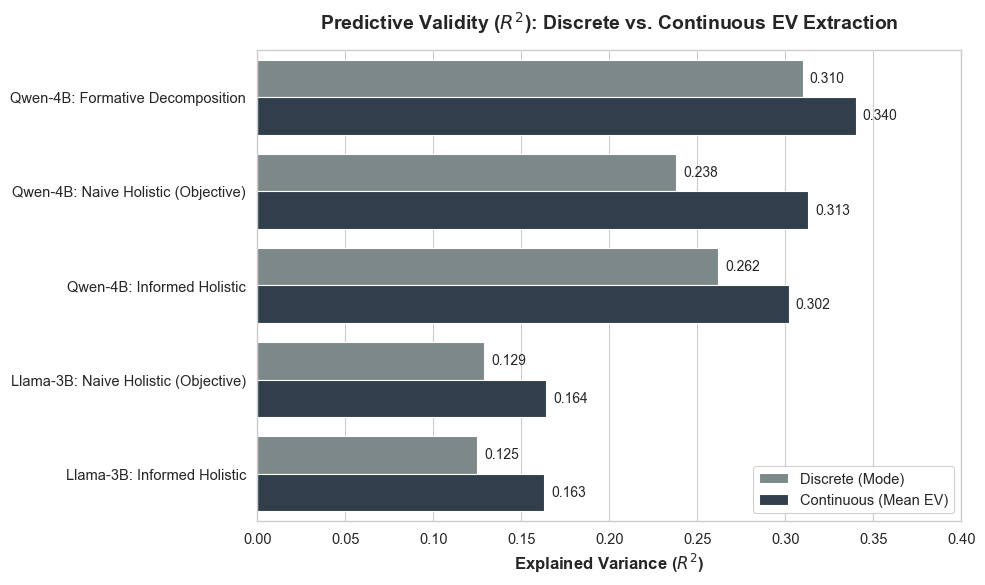

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the Data
# Note: I ordered these logically to group Qwen and Llama separately,
# with the Formative model sitting at the top as the benchmark.
data = [
    {"Model & Architecture", "Extraction Method", "R_Squared"},
    {"Qwen-4B: Formative Decomposition", "Discrete (Mode)", 0.310},
    {"Qwen-4B: Formative Decomposition", "Continuous (Mean EV)", 0.340},
    {"Qwen-4B: Naive Holistic (Objective)", "Discrete (Mode)", 0.238},
    {"Qwen-4B: Naive Holistic (Objective)", "Continuous (Mean EV)", 0.313},
    {"Qwen-4B: Informed Holistic", "Discrete (Mode)", 0.262},
    {"Qwen-4B: Informed Holistic", "Continuous (Mean EV)", 0.302},
    {"Llama-3B: Naive Holistic (Objective)", "Discrete (Mode)", 0.129},
    {"Llama-3B: Naive Holistic (Objective)", "Continuous (Mean EV)", 0.164},
    {"Llama-3B: Informed Holistic", "Discrete (Mode)", 0.125},
    {"Llama-3B: Informed Holistic", "Continuous (Mean EV)", 0.163}
]

# Convert to DataFrame properly
df = pd.DataFrame([
    ["Qwen-4B: Formative Decomposition", "Discrete (Mode)", 0.310],
    ["Qwen-4B: Formative Decomposition", "Continuous (Mean EV)", 0.340],
    ["Qwen-4B: Naive Holistic (Objective)", "Discrete (Mode)", 0.238],
    ["Qwen-4B: Naive Holistic (Objective)", "Continuous (Mean EV)", 0.313],
    ["Qwen-4B: Informed Holistic", "Discrete (Mode)", 0.262],
    ["Qwen-4B: Informed Holistic", "Continuous (Mean EV)", 0.302],
    ["Llama-3B: Naive Holistic (Objective)", "Discrete (Mode)", 0.129],
    ["Llama-3B: Naive Holistic (Objective)", "Continuous (Mean EV)", 0.164],
    ["Llama-3B: Informed Holistic", "Discrete (Mode)", 0.125],
    ["Llama-3B: Informed Holistic", "Continuous (Mean EV)", 0.163]
], columns=["Model & Architecture", "Extraction Method", "R_Squared"])

# 2. Set Thesis-Grade Aesthetics
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(10, 6))

# 3. Create the Barplot
# Using a muted blue/orange palette to keep it professional
palette = {"Discrete (Mode)": "#7b8a8b", "Continuous (Mean EV)": "#2c3e50"}

ax = sns.barplot(
    data=df,
    x="R_Squared",
    y="Model & Architecture",
    hue="Extraction Method",
    palette=palette,
    orient='h'
)

# 4. Add Data Labels to the Bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5, fontsize=10)

# 5. Formatting and Polish
plt.title("Predictive Validity ($R^2$): Discrete vs. Continuous EV Extraction",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Explained Variance ($R^2$)", fontsize=12, fontweight='bold')
# Remove the y-axis label since the categories are self-explanatory
plt.ylabel("")

# Adjust x-axis limit slightly to make room for the bar labels
plt.xlim(0, 0.40)

# Clean up the legend
plt.legend(title="", loc='lower right', frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()
# plt.savefig('variance_recovery_plot.png', dpi=300) # Uncomment to save in high-res